<a href="https://colab.research.google.com/github/tung20-1/CNN-Predicting-Handwritten-Digits/blob/main/Train_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import thư viện cần thiết

In [1]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Tải dataset CNN



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


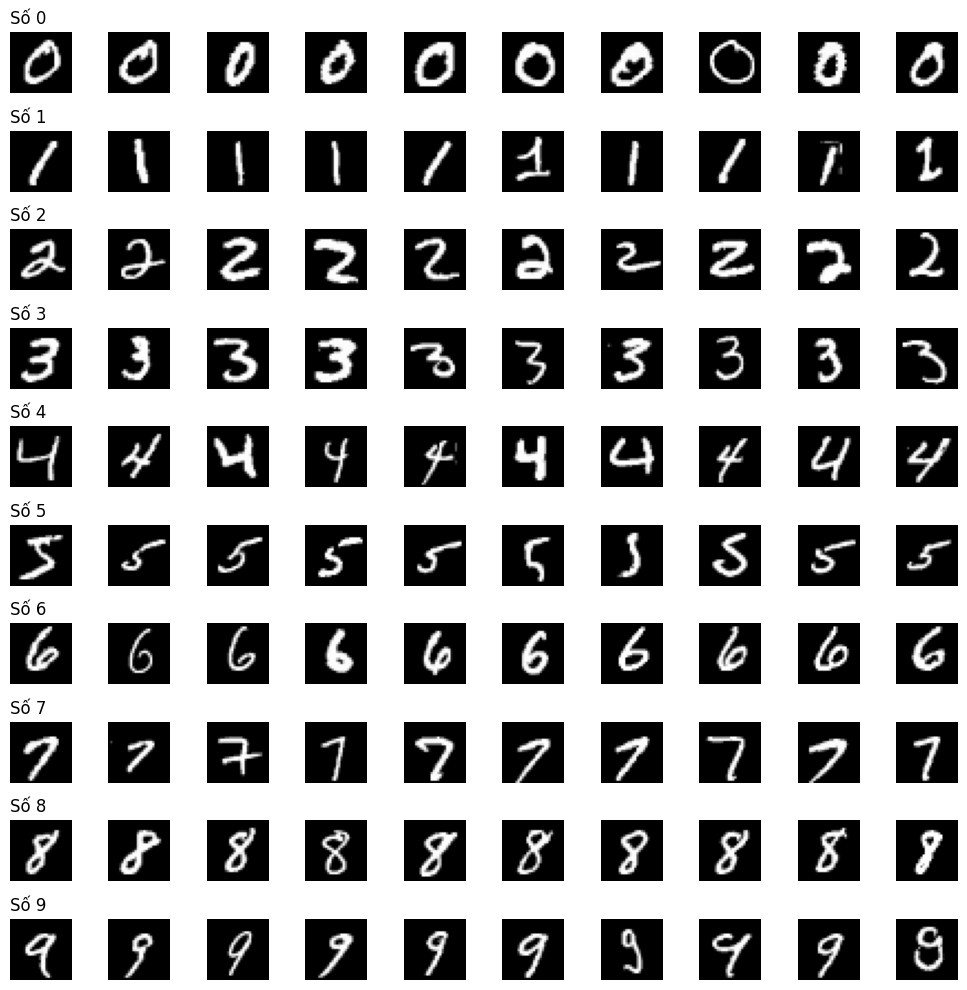

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

fig, axes = plt.subplots(10, 10, figsize=(10, 10))

for digit in range(10):

    indices = np.where(y_train == digit)[0][:10]

    for j, index in enumerate(indices):

        axes[digit, j].imshow( x_train[index], cmap="gray")
        axes[digit, j].axis("off")

        if j == 0:
            axes[digit, j].set_title(
                f"Số {digit}",
                loc="left"
            )

plt.tight_layout()
plt.show()

# Tiền xử lý dữ liệu

In [3]:
# Nếu dữ liệu chưa normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Thêm chiều channel nếu chưa có
if x_train.ndim == 3:
    x_train_cnn = np.expand_dims(x_train, axis=-1)
    x_test_cnn = np.expand_dims(x_test, axis=-1)
else:
    x_train_cnn = x_train
    x_test_cnn = x_test

print("x_train CNN:", x_train_cnn.shape)
print("x_test CNN:", x_test_cnn.shape)

x_train CNN: (60000, 28, 28, 1)
x_test CNN: (10000, 28, 28, 1)


# Xây dựng model

In [4]:
cnn_model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),

    # CNN layer 1
    tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),

    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # CNN layer 2
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),

    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Chuyển feature map thành vector
    tf.keras.layers.Flatten(),

    # Fully connected
    tf.keras.layers.Dense(128, activation="relu"),

    # Output 10 chữ số
    tf.keras.layers.Dense(10, activation="softmax")
])

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Compile model
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy", #Đo mức độ dự đoán sai
    metrics=["accuracy"]
)

In [15]:
# Train model

history_cnn = cnn_model.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 32ms/step - accuracy: 0.9902 - loss: 0.0292 - val_accuracy: 0.9883 - val_loss: 0.0421
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 31ms/step - accuracy: 0.9943 - loss: 0.0157 - val_accuracy: 0.9891 - val_loss: 0.0413
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.9958 - loss: 0.0116 - val_accuracy: 0.9901 - val_loss: 0.0440
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.9971 - loss: 0.0087 - val_accuracy: 0.9901 - val_loss: 0.0444
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9966 - loss: 0.0101 - val_accuracy: 0.9888 - val_loss: 0.0436
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - accuracy: 0.9975 - loss: 0.0073 - val_accuracy: 0.9898 - val_loss: 0.0485
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - accuracy: 0.9982 - loss: 0.0062 - val_accuracy: 0.9893 - val_loss: 0.0472
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 33s 22ms/step - accuracy: 0.9981 -

## Biểu đồ accuracy - loss

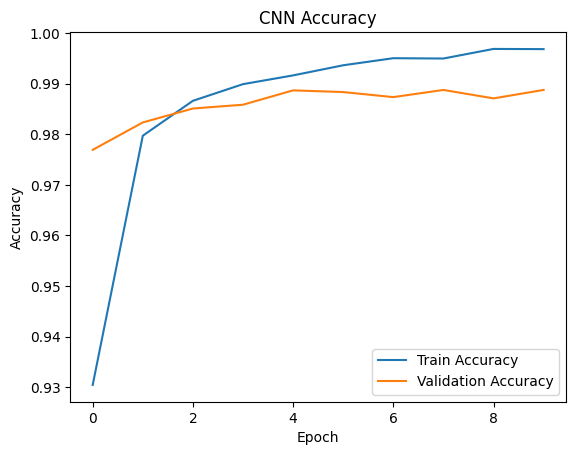

In [7]:
plt.plot(history_cnn.history["accuracy"], label="Train Accuracy")
plt.plot(history_cnn.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")
plt.legend()
plt.show()

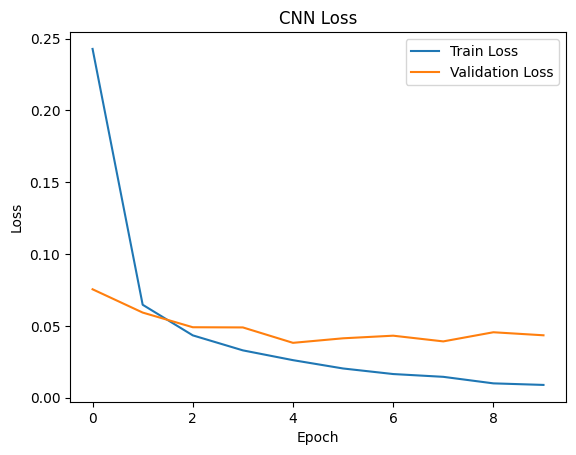

In [8]:
plt.plot(history_cnn.history["loss"], label="Train Loss")
plt.plot(history_cnn.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss")
plt.legend()
plt.show()

# Đánh giá

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9891 - loss: 0.0378
Test Loss: 0.0378
Test Accuracy: 98.91%
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


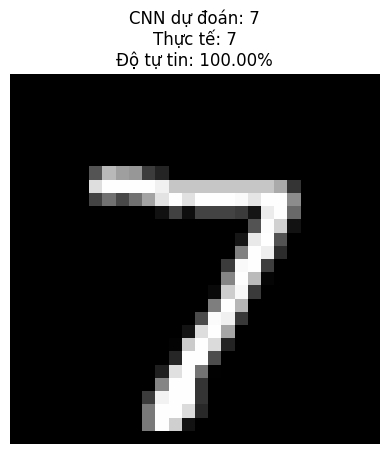

In [9]:
test_loss, test_accuracy = cnn_model.evaluate(x_test_cnn, y_test)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


predictions_cnn = cnn_model.predict(x_test_cnn)
predicted_labels_cnn = np.argmax(predictions_cnn, axis=1)
# test
index = 0

predicted = predicted_labels_cnn[index]
actual = y_test[index]
confidence = predictions_cnn[index].max()

plt.imshow(x_test[index], cmap="gray")

plt.title(
    f"CNN dự đoán: {predicted}\n"
    f"Thực tế: {actual}\n"
    f"Độ tự tin: {confidence * 100:.2f}%"
)

plt.axis("off")
plt.show()

# Main UI

## Cài đặt gradio


In [10]:
!pip install -q gradio

## thư viện cần thiết

In [11]:
import gradio as gr
import numpy as np
import cv2
import matplotlib.pyplot as plt

## Tiền xử lý ảnh vẽ

In [12]:
def preprocess_sketch(editor_value):

    if editor_value is None:
        raise gr.Error("Bạn chưa vẽ chữ số.")

    #Lấy ảnh từ Sketchpad
    if isinstance(editor_value, dict):
        img = editor_value.get("composite")
    else:
        img = editor_value

    if img is None:
        raise gr.Error("Không tìm thấy ảnh.")

    img = np.array(img)

    #Chuyển grayscale
    if img.ndim == 3:

        if img.shape[2] == 4:
            gray = cv2.cvtColor(img, cv2.COLOR_RGBA2GRAY)
        else:
            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        gray = img.copy()

    gray = gray.astype(np.uint8)


    #Đảo màu
    #nền trắng + chữ đen -> nền đen + chữ trắng
    if gray.mean() > 127:
        gray = 255 - gray

    #Binary CHỈ để tìm vùng chữ
    _, mask = cv2.threshold(gray, 20, 255, cv2.THRESH_BINARY)

    #Tìm vùng chứa chữ
    points = cv2.findNonZero(mask)

    if points is None:
        raise gr.Error("Không tìm thấy chữ số.")

    x, y, w, h = cv2.boundingRect(points)


    #QUAN TRỌNG:
    #crop từ GRAY chứ không crop từ mask
    digit = gray[y:y+h,x:x+w]

    #Resize giữ nguyên tỷ lệ
    height, width = digit.shape

    if height > width:
        new_height = 20
        new_width = max(1, int(width * 20 / height))
    else:
        new_width = 20
        new_height = max(1, int(height * 20 / width))

    digit = cv2.resize(digit, (new_width, new_height), interpolation=cv2.INTER_AREA)

    #Đặt vào canvas 28x28
    canvas = np.zeros((28, 28), dtype=np.uint8)

    x_offset = (28 - new_width) // 2
    y_offset = (28 - new_height) // 2

    canvas[y_offset:y_offset + new_height, x_offset:x_offset + new_width] = digit

    #Căn theo trọng tâm
    #gần cách MNIST được chuẩn hóa
    moments = cv2.moments(canvas)

    if moments["m00"] != 0:

        cx = moments["m10"] / moments["m00"]
        cy = moments["m01"] / moments["m00"]

        shift_x = int(round(13.5 - cx))
        shift_y = int(round(13.5 - cy))

        matrix = np.float32([[1, 0, shift_x], [0, 1, shift_y]])

        canvas = cv2.warpAffine(canvas, matrix, (28, 28))

    #Normalize
    image_array = (canvas.astype("float32")/ 255.0)

    return image_array

## CNN dự đoán

In [13]:
def predict_digit(editor_value):
    #Tiền xử lý ảnh vẽ
    image_array = preprocess_sketch(editor_value)

    #CNN cần shape (1, 28, 28, 1)
    image_input = image_array[np.newaxis, ..., np.newaxis]

    #CNN dự đoán
    prediction = cnn_model.predict(image_input, verbose=0)[0]

    predicted_digit = int(np.argmax(prediction))

    confidence = float(np.max(prediction))

    #Top 5 Predictions
    top5 = np.argsort(prediction)[-5:][::-1]
    top_digits = top5
    top_scores = prediction[top5]

    fig, ax = plt.subplots(figsize=(6, 3))

    ax.barh([str(x) for x in top_digits[::-1]], top_scores[::-1])

    ax.set_xlim(0, 1)
    ax.set_xlabel("Confidence")
    ax.set_title("Top-5 Predictions")

    # Hiển thị %
    for i, score in enumerate(top_scores[::-1]):
        ax.text(min(score + 0.01, 0.95), i, f"{score * 100:.2f}%",va="center")

    plt.tight_layout()

    #Lấy ảnh mẫu MNIST
    #của số được dự đoán
    indices = np.where(y_train == predicted_digit)[0]

    sample_index = indices[0]

    predicted_image = x_train[sample_index]

    #Nếu có channel thì bỏ đi
    predicted_image = np.squeeze(predicted_image)

    #Nếu dữ liệu đang ở 0-1
    #thì chuyển thành 0-255 để hiển thị
    if predicted_image.max() <= 1:
        predicted_image = (predicted_image * 255).astype(np.uint8)

    #Text kết quả
    result = (
        f"Dự đoán: {predicted_digit} "
        f"({confidence * 100:.2f}%)**"
    )

    return (result,fig,predicted_image)

## Giao diện

In [14]:
blank_canvas = np.full((400, 400, 3), 255, dtype=np.uint8)

with gr.Blocks(title="Nhận dạng chữ viết tay CNN") as demo:
    gr.Markdown("Nhận dạng chữ viết tay (CNN - Keras)")

    with gr.Row():

        # BÊN TRÁI - VẼ
        with gr.Column(scale=1):

            sketch = gr.Sketchpad(value=blank_canvas, type="numpy", label="Vẽ chữ số", height=430,

              # Cố định canvas
              canvas_size=(400, 400),fixed_canvas=True,

              # Cố định bút
              brush=gr.Brush(default_size=8, colors=["#000000"], default_color="#000000", color_mode="fixed"),
              eraser=gr.Eraser(default_size=12)
          )

        # BÊN PHẢI
        with gr.Column(scale=1):

            # Trên: Top-5 dự đoán
            prediction_plot = gr.Plot(label="Top-5 Predictions")

            # Dưới: ảnh mẫu số dự đoán
            predicted_image = gr.Image(label="Ảnh mẫu của số dự đoán", height=180, image_mode="L")

    # KẾT QUẢ
    result = gr.Markdown("Dự đoán: Chưa có")

   # BUTTON
    with gr.Row():
        predict_button = gr.Button("Dự đoán", variant="primary")

        clear_button = gr.ClearButton(
            components=[sketch, prediction_plot, predicted_image, result],value="Xóa")

    # SỰ KIỆN DỰ ĐOÁN
    predict_button.click(fn=predict_digit, inputs=sketch, outputs=[result, prediction_plot, predicted_image])

demo.launch(
    debug=True
)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://6d28d726bd363dfc5c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://6d28d726bd363dfc5c.gradio.live
